In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
from mne.filter import filter_data

### Config

In [2]:
CHANNEL_NAMES = [
    "FP1", "F3",  "F7",  "C3",
    "T3",  "P3",  "T5",  "O1",
    "FP2", "F4",  "F8",  "C4",
    "T4",  "P4",  "T6",  "O2"
]

SUBJECT = "X"
ROOT    = f"../data/subject{SUBJECT}"
DATE    = "20260618"

files  = [f for f in os.listdir(ROOT) if f.endswith(".csv")]
STAMPS = np.unique([f.split("_")[-1][:-4] for f in files if f"{SUBJECT}_eeg_{DATE}" in f])

STAMP_ID = 0
STAMP    = STAMPS[STAMP_ID]
print(f"Available: {STAMPS}")
print(f"Loading   STAMP={STAMP}")

FS = 250.

# Stimulus-locked window (around onset)
PRE_STIM  = 0.2   # s before stimulus
POST_STIM = 1.5   # s after stimulus

# Movement-locked window (around button press)
PRE_PRESS  = 2.0  # s before press  (captures BP ramp)
POST_PRESS = 0.5  # s after press

Available: ['101323']
Loading   STAMP=101323


#### Load data

In [3]:
# Loading EEG
df_eeg     = pd.read_csv(f"{ROOT}/{SUBJECT}_eeg_{DATE}_{STAMP}.csv")
timestamps = df_eeg.lsl_timestamp.values
EEG        = df_eeg.iloc[:, 1:-1].values
button     = df_eeg.iloc[:, -1].values.astype(bool)

N, N_CHANNELS = EEG.shape
print(f"EEG shape: {EEG.shape}  ({N / FS:.1f} s)")

EEG shape: (267752, 16)  (1071.0 s)


In [4]:
# Loading markers
df_markers = pd.read_csv(f"{ROOT}/{SUBJECT}_markers_{DATE}_{STAMP}.csv")

#### Align marker timestamps to EEG clock

EEG timestamps are saved with `time_correction` applied (wall-clock reference),
but markers used raw `local_clock()` (boot-relative).  
We recover the offset using the first button-press rising edge visible in both signals.

> **Fixed in `gng_task.py`** — future sessions won't need this cell.

In [5]:
# Rising edges in EEG button channel (ch16)
BUTTON_EDGES = np.where(np.diff(button.astype(int)) > 0)[0]

# First selfpaced press in markers (code 41) as the sync anchor
SP_MKR_TIMES = df_markers.loc[df_markers.marker_code == 41].lsl_timestamp.values

if len(BUTTON_EDGES) > 0 and len(SP_MKR_TIMES) > 0:
    EEG_FIRST_PRESS = timestamps[BUTTON_EDGES[0] + 1]
    MKR_FIRST_PRESS = SP_MKR_TIMES[0]
    TS_OFFSET = EEG_FIRST_PRESS - MKR_FIRST_PRESS
    df_markers["lsl_timestamp"] = df_markers["lsl_timestamp"] + TS_OFFSET
    print(f"TS_OFFSET = {TS_OFFSET:.3f} s  (applied to all marker timestamps)")
else:
    TS_OFFSET = 0.0
    print("WARNING: could not compute TS_OFFSET — check BUTTON_EDGES and SP_MKR_TIMES")

TS_OFFSET = 1781276233.288 s  (applied to all marker timestamps)


In [6]:
df_eeg.head()

,lsl_timestamp,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15,ch16
0,1.781811e+09,-69388.476562,-48542.621094,-76736.929688,87602.562500,-16805.109375,-1590.550049,-75213.710938,-42676.359375,-89829.601562,1702.670044,-89470.453125,1074564.375,902828.9375,-94792.492188,-22978.490234,-66733.359375,0.0
1,1.781811e+09,-69284.148438,-48382.230469,-76552.929688,87415.070312,-16955.849609,-1670.479980,-75263.859375,-42828.710938,-90230.593750,1806.199951,-89552.257812,1074703.500,902940.0000,-94934.109375,-22934.230469,-66707.882812,0.0
2,1.781811e+09,-69393.851562,-48537.789062,-76814.179688,87555.890625,-16817.990234,-1572.040039,-75239.992188,-42675.289062,-90883.710938,2127.260010,-89699.507812,1074977.375,903183.7500,-95217.617188,-22914.109375,-66693.671875,0.0
3,1.781811e+09,-69573.023438,-48809.500000,-77183.250000,87854.960938,-16553.250000,-1407.890015,-75161.937500,-42396.878906,-90851.789062,2206.649902,-89704.070312,1075060.500,903237.4375,-95240.960938,-22946.029297,-66705.203125,0.0
4,1.781811e+09,-69579.992188,-48822.109375,-77138.726562,87860.593750,-16559.150391,-1428.280029,-75158.179688,-42412.968750,-90162.460938,1924.489990,-89552.531250,1074782.375,903045.3750,-94961.203125,-22979.019531,-66718.609375,0.0


In [7]:
df_markers.head(20)

,lsl_timestamp,marker_code,marker_label,trial_type
0,1.781811e+09,40,selfpaced_start,selfpaced
1,1.781811e+09,41,selfpaced_press,selfpaced
2,1.781811e+09,41,selfpaced_press,selfpaced
3,1.781811e+09,41,selfpaced_press,selfpaced
4,1.781811e+09,41,selfpaced_press,selfpaced
5,1.781811e+09,41,selfpaced_press,selfpaced
6,1.781811e+09,41,selfpaced_press,selfpaced
7,1.781811e+09,41,selfpaced_press,selfpaced
8,1.781811e+09,41,selfpaced_press,selfpaced
9,1.781811e+09,41,selfpaced_press,selfpaced


In [8]:
df_markers.trial_type.value_counts()

trial_type
go           300
nogo         201
selfpaced     59
Name: count, dtype: int64

### Preprocess EEG

In [9]:
EEG = filter_data(EEG.T[None], FS, 0.5, 28., verbose=False).squeeze()

In [10]:
# Apply CAR
EEG -= EEG.mean(axis=0, keepdims=True)

---
## Stimulus-locked ERPs: GO vs NOGO

Epochs locked to stimulus onset.  
Look for **N2** (~200 ms) and **P3** (~300–400 ms), largest at frontocentral electrodes.

| Marker code | Event      |
|-------------|------------|
| 10          | go_onset   |
| 20          | nogo_onset |

In [11]:
N_PRE_STIM  = int(PRE_STIM  * FS)
N_POST_STIM = int(POST_STIM * FS)
N_STIM      = N_PRE_STIM + N_POST_STIM + 1
T_STIM      = np.linspace(-PRE_STIM, POST_STIM, N_STIM)

In [12]:
go_onsets = df_markers.loc[df_markers.marker_code == 10].lsl_timestamp.values

GO_ERP = []
for onset in go_onsets:
    idx = np.searchsorted(timestamps, onset)
    i0  = idx - N_PRE_STIM
    i1  = idx + N_POST_STIM + 1
    if i0 >= 0 and i1 <= N:
        GO_ERP.append(EEG[:, i0:i1])

GO_ERP = np.stack(GO_ERP)
print(f"GO epochs: {len(GO_ERP)}")

GO epochs: 99


In [13]:
nogo_onsets = df_markers.loc[df_markers.marker_code == 20].lsl_timestamp.values

NOGO_ERP = []
for onset in nogo_onsets:
    idx = np.searchsorted(timestamps, onset)
    i0  = idx - N_PRE_STIM
    i1  = idx + N_POST_STIM + 1
    if i0 >= 0 and i1 <= N:
        NOGO_ERP.append(EEG[:, i0:i1])

NOGO_ERP = np.stack(NOGO_ERP)
print(f"NOGO epochs: {len(NOGO_ERP)}")

NOGO epochs: 100


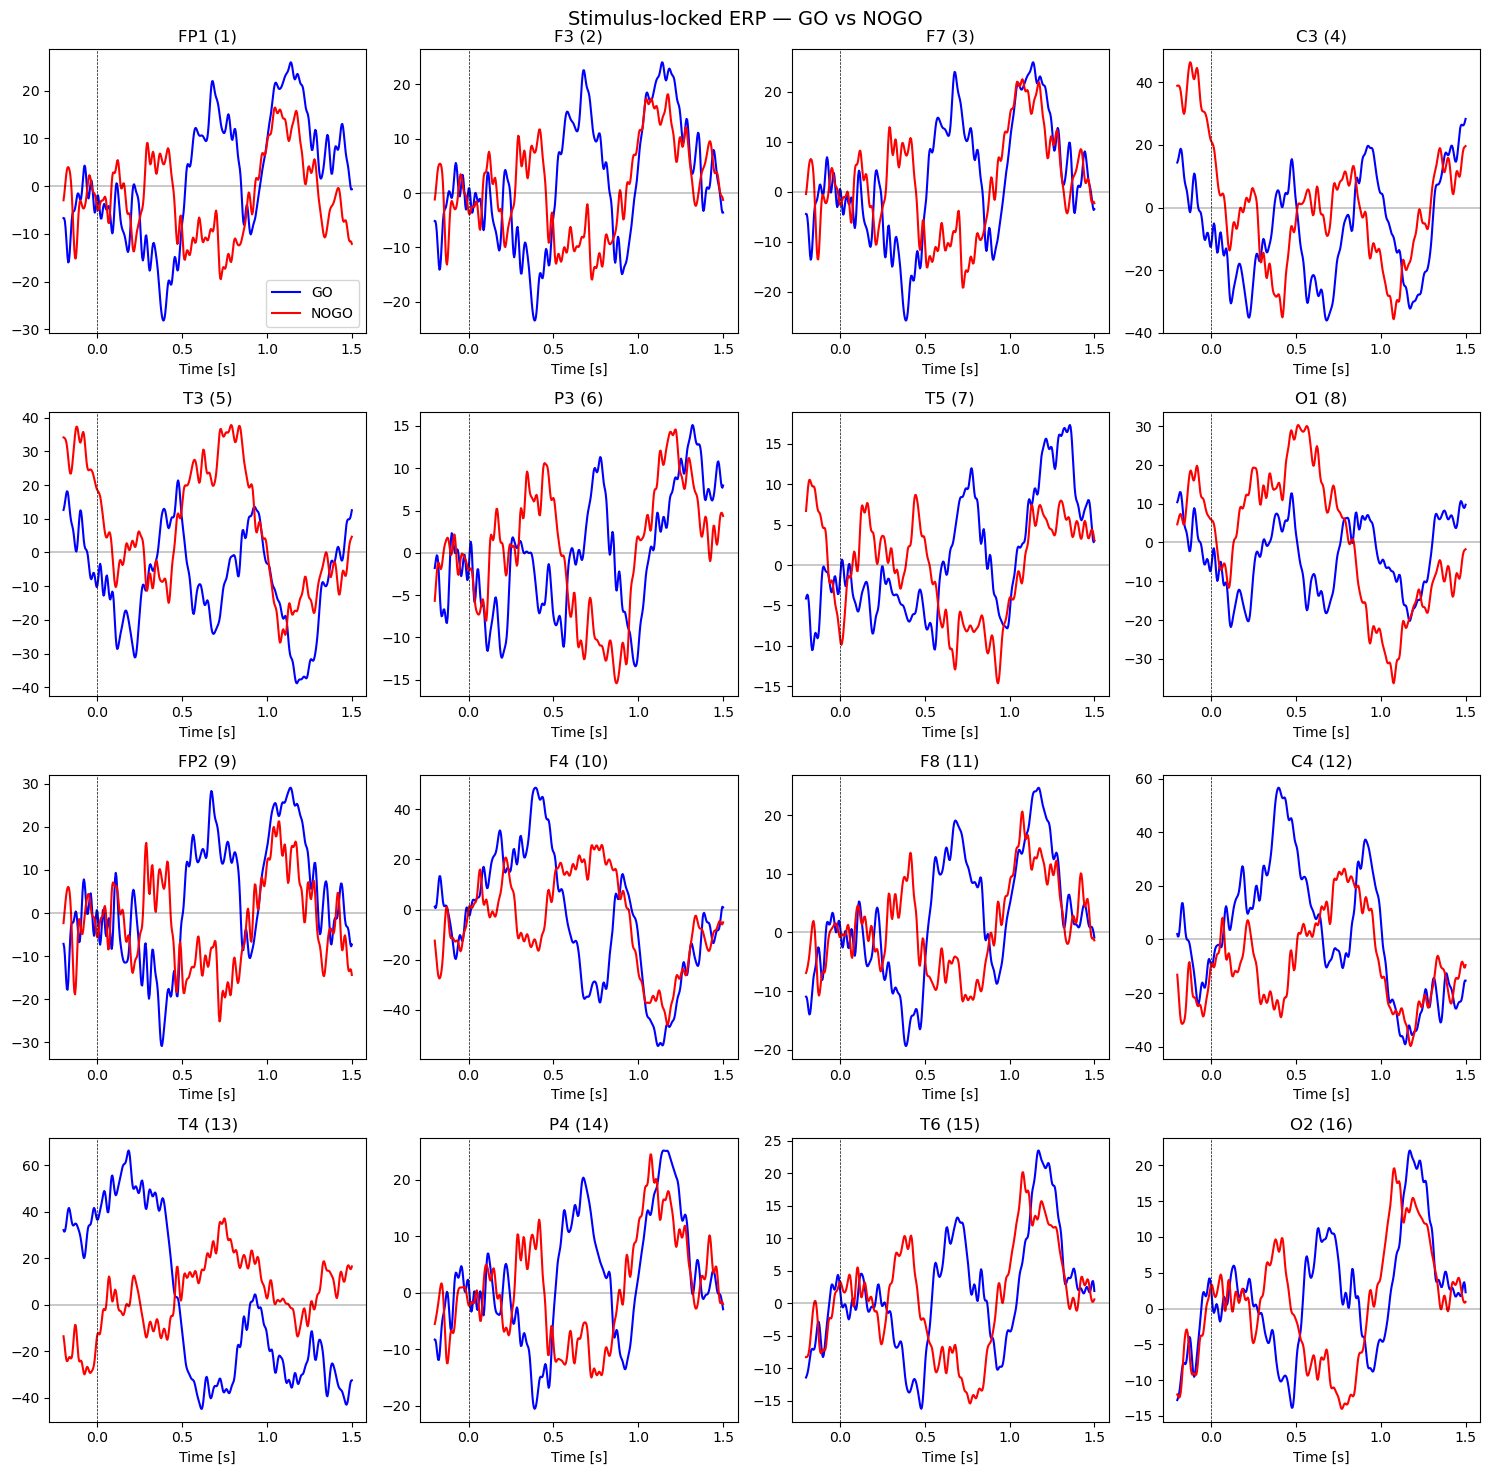

In [14]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_STIM, GO_ERP.mean(0)[pos],   "b", label="GO")
    plt.plot(T_STIM, NOGO_ERP.mean(0)[pos], "r", label="NOGO")
    plt.axvline(0, color="k", linewidth=0.5, linestyle="--")
    plt.axhline(0, color="k", linewidth=0.3)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    if pos == 0:
        plt.legend()
plt.suptitle("Stimulus-locked ERP — GO vs NOGO", fontsize=14)
plt.tight_layout()

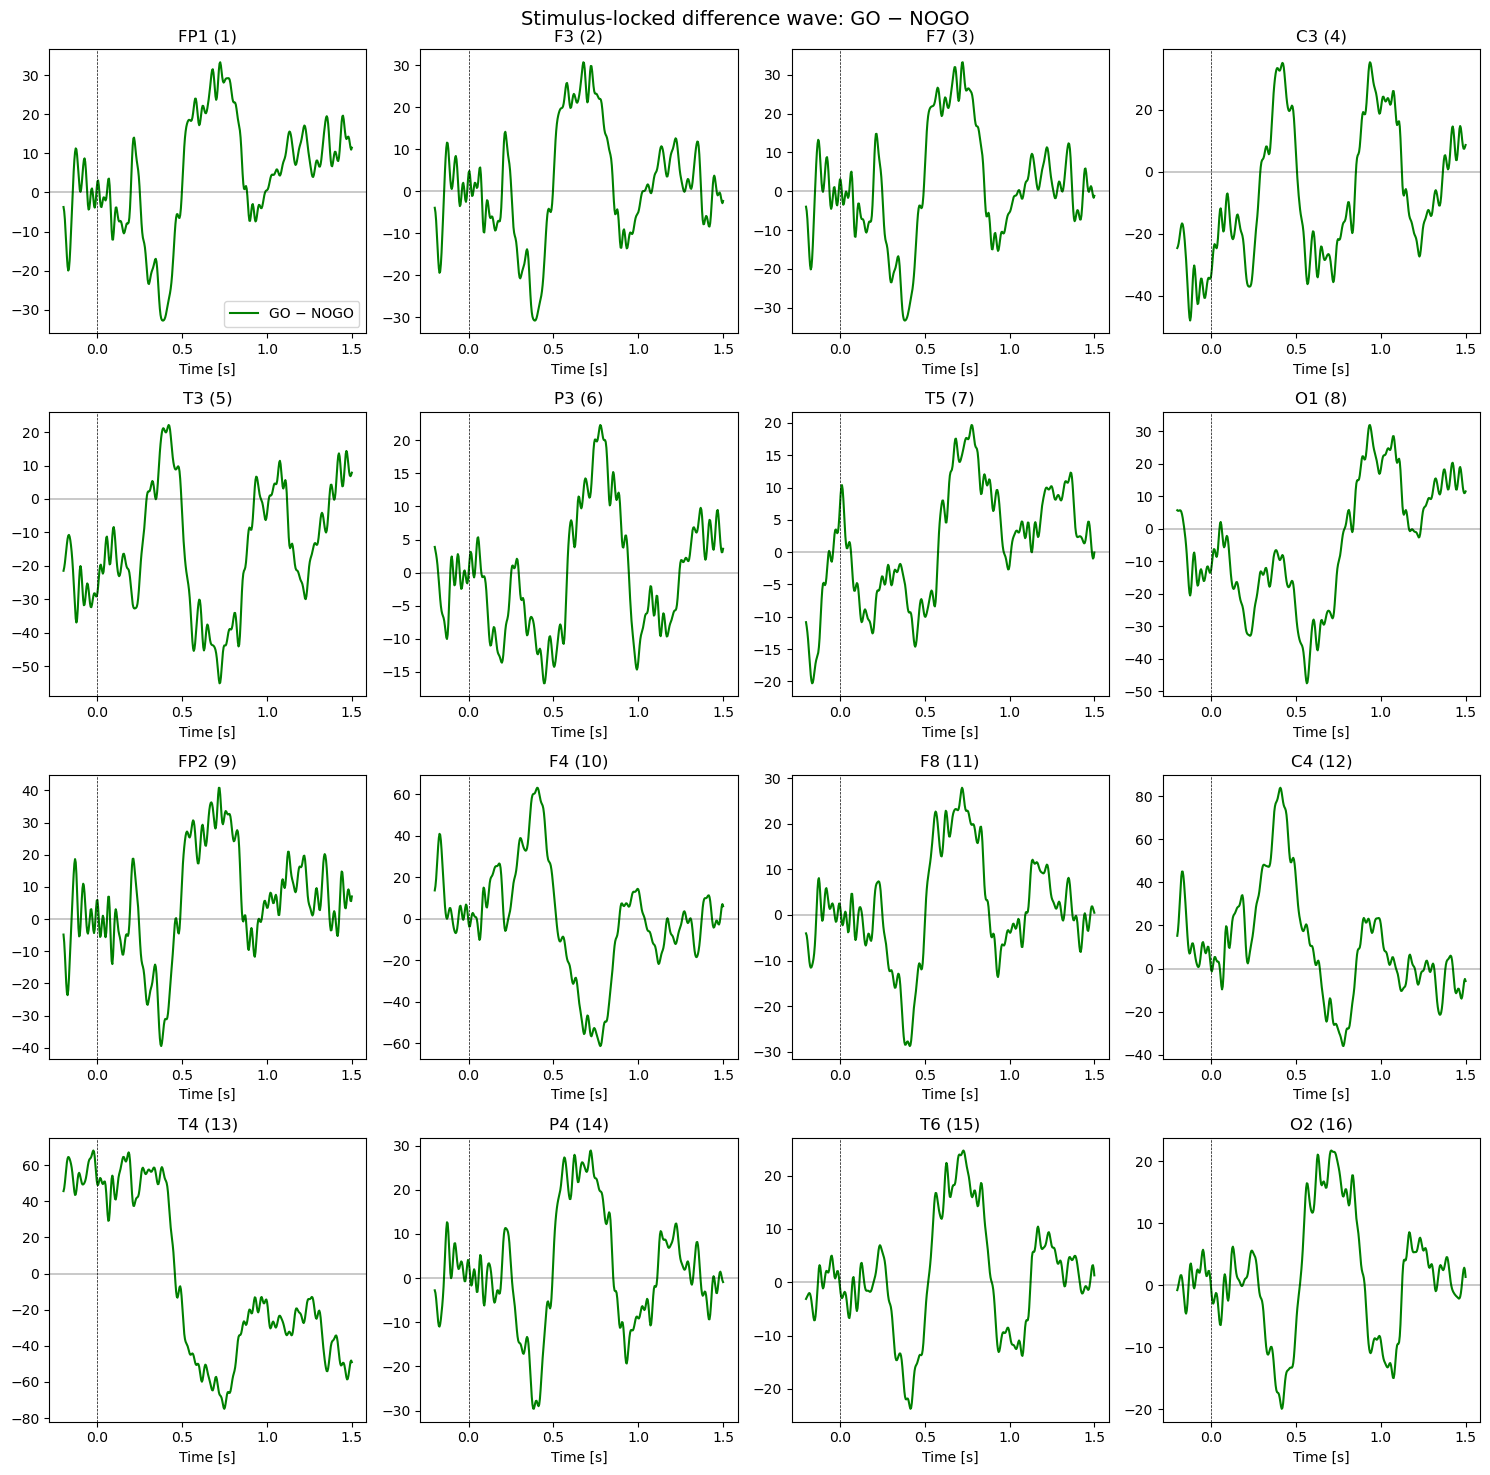

In [15]:
# GO - NOGO difference wave
GO_MINUS_NOGO = GO_ERP.mean(axis=0) - NOGO_ERP.mean(axis=0)

plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_STIM, GO_MINUS_NOGO[pos], "g", label="GO − NOGO")
    plt.axvline(0, color="k", linewidth=0.5, linestyle="--")
    plt.axhline(0, color="k", linewidth=0.3)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    if pos == 0:
        plt.legend()
plt.suptitle("Stimulus-locked difference wave: GO − NOGO", fontsize=14)
plt.tight_layout()

---
## Movement-locked ERPs: GO hit vs Self-paced

Epochs locked to **button press**.  
Look for the **Bereitschaftspotential** — slow negative ramp starting ~1–1.5 s before press, maximal at **Cz** (ch C3, index 3 in this cap).

| Marker code | Event             |
|-------------|-------------------|
| 30          | button_press (GO) |
| 41          | selfpaced_press   |

In [16]:
N_PRE_PRESS  = int(PRE_PRESS  * FS)
N_POST_PRESS = int(POST_PRESS * FS)
N_PRESS      = N_PRE_PRESS + N_POST_PRESS + 1
T_PRESS      = np.linspace(-PRE_PRESS, POST_PRESS, N_PRESS)

In [17]:
# GO hits only (button_press on go trials)
go_press_times = df_markers.loc[
    (df_markers.marker_code == 30) & (df_markers.trial_type == "go")
].lsl_timestamp.values

GO_PRESS_ERP = []
for t in go_press_times:
    idx = np.searchsorted(timestamps, t)
    i0  = idx - N_PRE_PRESS
    i1  = idx + N_POST_PRESS + 1
    if i0 >= 0 and i1 <= N:
        GO_PRESS_ERP.append(EEG[:, i0:i1])

GO_PRESS_ERP = np.stack(GO_PRESS_ERP)
print(f"GO hit press epochs: {len(GO_PRESS_ERP)}")

GO hit press epochs: 99


In [18]:
# Self-paced presses (voluntary, no cue)
sp_press_times = df_markers.loc[df_markers.marker_code == 41].lsl_timestamp.values
print(f"Self-paced press events found: {len(sp_press_times)}")

SP_ERP = []
for t in sp_press_times:
    idx = np.searchsorted(timestamps, t)
    i0  = idx - N_PRE_PRESS
    i1  = idx + N_POST_PRESS + 1
    if i0 >= 0 and i1 <= N:
        SP_ERP.append(EEG[:, i0:i1])

SP_ERP = np.stack(SP_ERP) if SP_ERP else None
print(f"SP epochs after boundary check: {len(SP_ERP) if SP_ERP is not None else 0}")

Self-paced press events found: 57
SP epochs after boundary check: 56


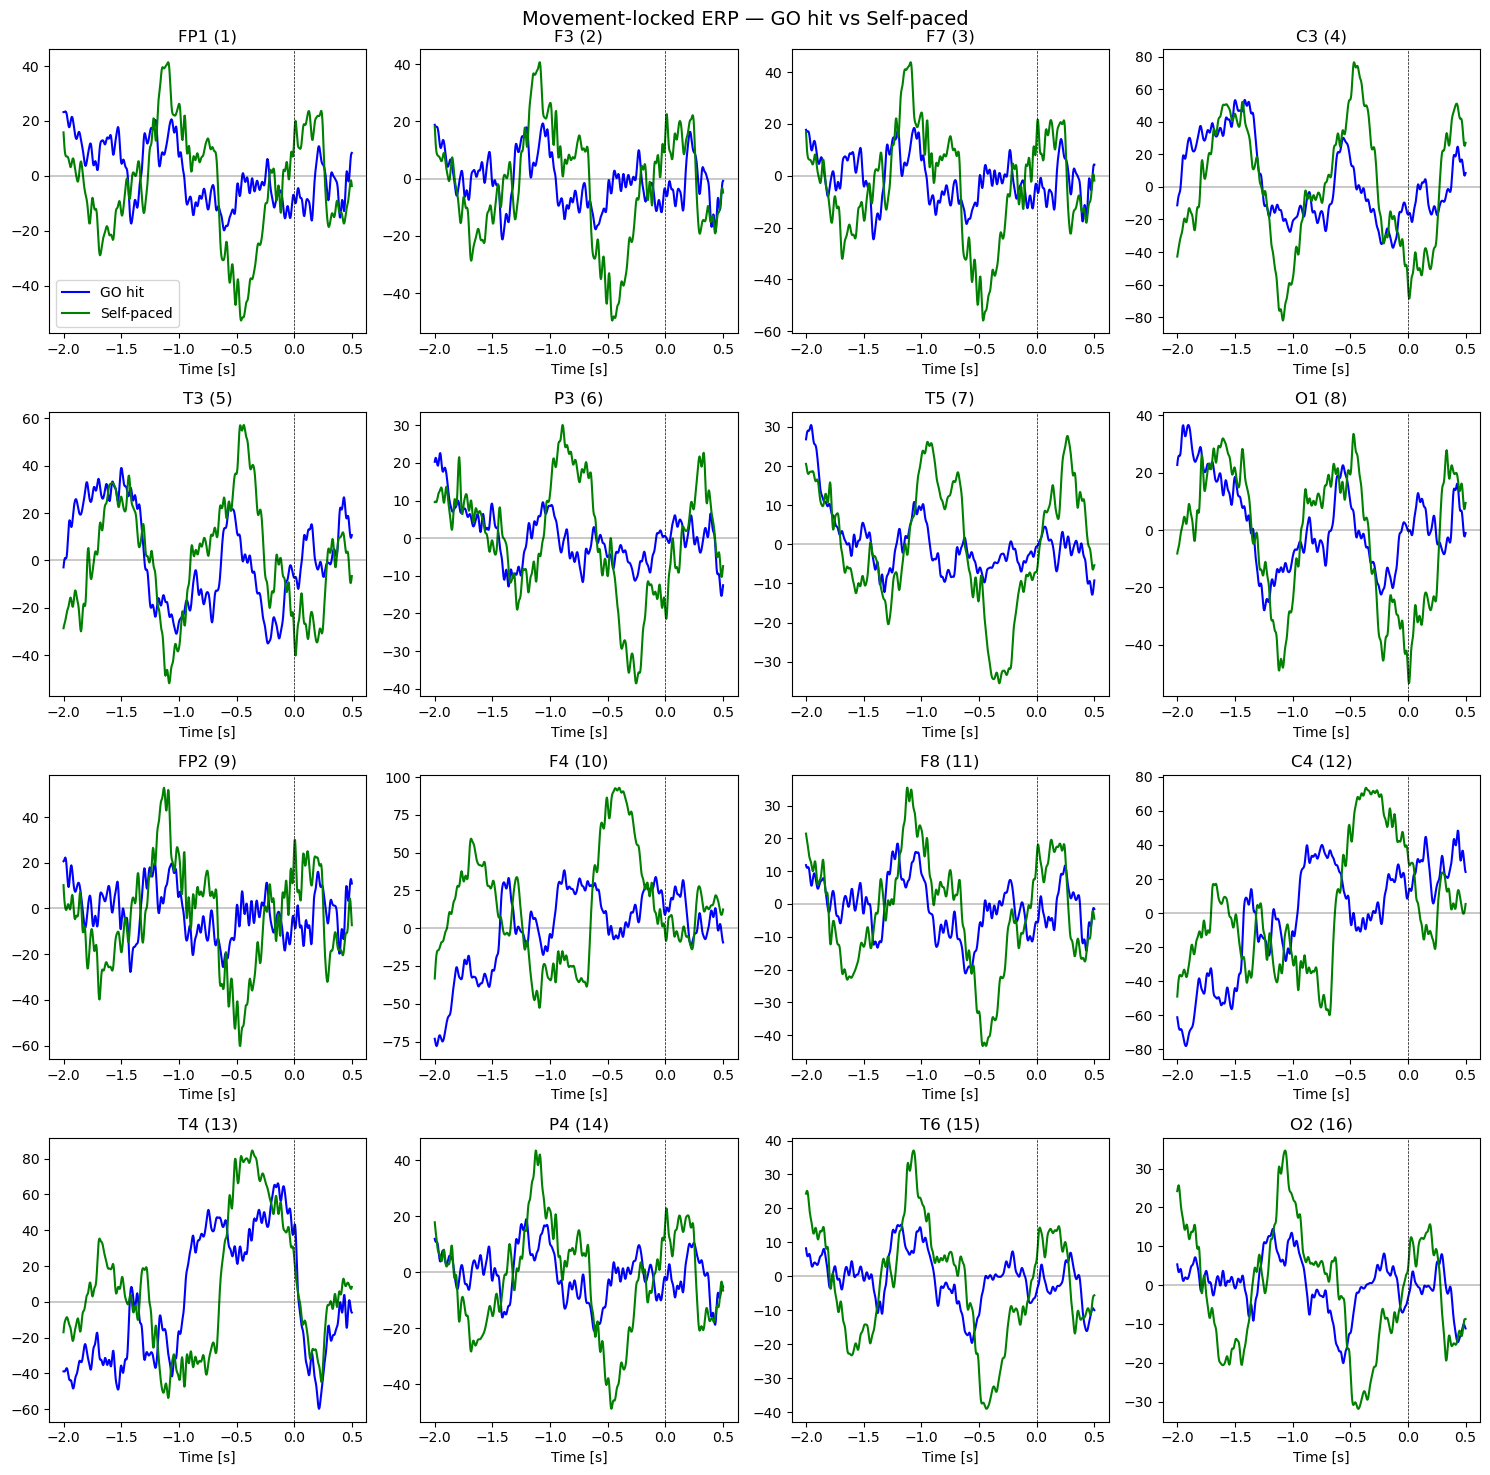

In [19]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_PRESS, GO_PRESS_ERP.mean(0)[pos], "b", label="GO hit")
    if SP_ERP is not None:
        plt.plot(T_PRESS, SP_ERP.mean(0)[pos], "g", label="Self-paced")
    plt.axvline(0, color="k", linewidth=0.5, linestyle="--")
    plt.axhline(0, color="k", linewidth=0.3)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    if pos == 0:
        plt.legend()
plt.suptitle("Movement-locked ERP — GO hit vs Self-paced", fontsize=14)
plt.tight_layout()

---
## Summary: all conditions at Cz

Cz is channel index 3 (C3 in this 16-ch cap — adjust `CZ` if needed).  
Stimulus-locked and movement-locked have different time axes — plotted side by side.

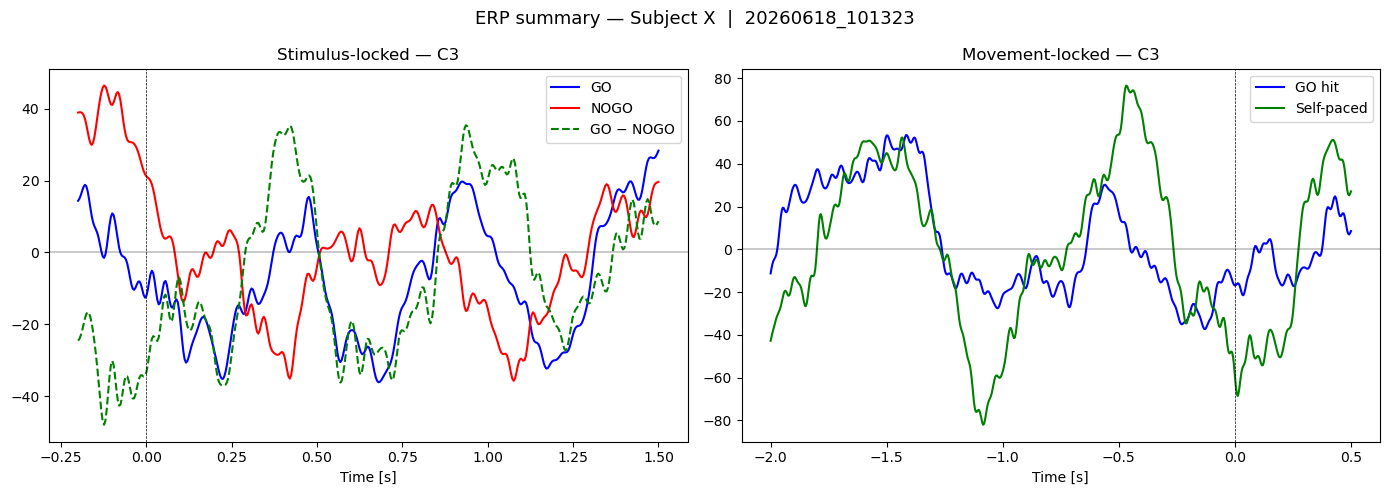

In [20]:
CZ = 3  # C3 position in this cap — adjust if your Cz is different

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_STIM, GO_ERP.mean(0)[CZ],   "b",   label="GO")
ax.plot(T_STIM, NOGO_ERP.mean(0)[CZ], "r",   label="NOGO")
ax.plot(T_STIM, GO_MINUS_NOGO[CZ],    "g--", label="GO − NOGO")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.axhline(0, color="k", linewidth=0.3)
ax.set_xlabel("Time [s]")
ax.set_title(f"Stimulus-locked — {CHANNEL_NAMES[CZ]}")
ax.legend()

ax = axes[1]
ax.plot(T_PRESS, GO_PRESS_ERP.mean(0)[CZ], "b", label="GO hit")
if SP_ERP is not None:
    ax.plot(T_PRESS, SP_ERP.mean(0)[CZ], "g", label="Self-paced")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.axhline(0, color="k", linewidth=0.3)
ax.set_xlabel("Time [s]")
ax.set_title(f"Movement-locked — {CHANNEL_NAMES[CZ]}")
ax.legend()

plt.suptitle(f"ERP summary — Subject {SUBJECT}  |  {DATE}_{STAMP}", fontsize=13)
plt.tight_layout()